[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mento-calc/mento/blob/main/docs/source/examples/OneWaySlab_check_ACI_318-19_imperial.ipynb)

In [1]:
# Google Colab does not ship mento, so install it when running there.
# Guarded so that building the documentation never shells out to pip.
import sys

if "google.colab" in sys.modules:
    %pip install mento

# One Way Slab check ACI 318-19 (US customary units)

The same example in US customary units. A concrete given in `psi` makes the section US customary, and everything mento prints follows: in, in², in²/ft, psi, ksi, kip and kip·ft, with bars named by their ASTM size (`#5`) and spacings after an `@`. See [Units](../user_guide/units.rst#us-customary-output).

**Define concrete and steel materials, and then assign the beam**

In [2]:
from mento import Concrete_ACI_318_19, SteelBar, OneWaySlab, Node, Forces
from mento import psi, ksi, inch, ft, kip

# Define materials and beam section
conc = Concrete_ACI_318_19(name="4000 psi", f_c=4000 * psi)
steel = SteelBar(name="Grade 60", f_y=60 * ksi)
slab = OneWaySlab(label="S101", concrete=conc, steel_bar=steel, width=60 * inch, height=8 * inch, c_c=0.75 * inch)
slab.data

Slab S101, $b$=60.00 in, $h$=8.00 in, $c_{c}$=0.75 in,                         Concrete 4000 psi, Rebar Grade 60.

**Set longitudinal reinforcement**

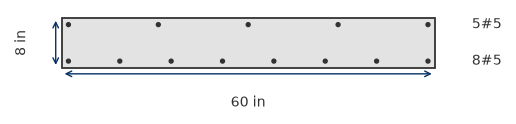

In [3]:
# Set bottom rebar
slab.set_slab_longitudinal_rebar_bot(d_b1=0.625 * inch, s_b1=8 * inch)  # #5 @ 8 in
# Set top rebar
slab.set_slab_longitudinal_rebar_top(d_b1=0.625 * inch, s_b1=12 * inch)  # #5 @ 12 in

# Plot the beam geometry and reinforcement
slab.plot()

**Create node and assign slab section and list of forces**

In [4]:
# Define forces
f1 = Forces(label="1.4D", V_z=9 * kip, M_y=45 * kip * ft)
f2 = Forces(label="1.2D+1.6L", V_z=11 * kip, M_y=-45 * kip * ft)
forces_list = [f1, f2]
# Create node and assign beam section and list of forces
node_1 = Node(section=slab, forces=[f1, f2])
node_1

Node ID: 1 - Section label: S101
Forces Applied:
  - Force ID: 1, Label: 1.4D, N_x: 0.00 kip, V_z: 9.00 kip, M_y: 45.00 ft·kip
  - Force ID: 2, Label: 1.2D+1.6L, N_x: 0.00 kip, V_z: 11.00 kip, M_y: -45.00 ft·kip

**Perform shear and bending checks**

In [5]:
# Perform all checks
node_1.check()
# Print results in Markdown format
node_1.results

Slab S101, $b$=60.00 in, $h$=8.00 in, $c_{c}$=0.75 in,                         Concrete 4000 psi, Rebar Grade 60.

Top longitudinal rebar: #5@12 in, $A_{s,top}$ = 1.53 in², $M_u$ = -45.0 kip·ft, $\phi M_n$ = 46.33 kip·ft → $\color{#efc200}{\text{DCR}=0.97}$ 

Bottom longitudinal rebar: #5@8 in, $A_{s,bot}$ = 2.3 in², $M_u$ = 45.0 kip·ft, $\phi M_n$ = 68.33 kip·ft → $\color{#439b00}{\text{DCR}=0.66}$ 

Shear reinforcing not assigned, $A_v$=0.0 in²/ft, $V_u$=11.0 kip, $\phi V_n$=24.4 kip → $\color{#439b00}{\text{DCR}=0.45}$ 

In [6]:
# Print shear results in more detailed format in a DataFrame
node_1.check_shear()

,Label,Comb.,"Av,min","Av,req",Av,Vu,Nu,ØVc,ØVs,ØVn,ØVmax,Vu≤ØVmax,Vu≤ØVn,DCR
0,,,in²/ft,in²/ft,in²/ft,kip,kip,kip,kip,kip,kip,,,
1,S101,1.4D,0.0,0.0,0.0,9.0,0.0,27.93,0.0,27.93,185.88,True,True,0.322
2,S101,1.2D+1.6L,0.0,0.0,0.0,11.0,0.0,24.4,0.0,24.4,182.35,True,True,0.451


In [7]:
# Print flexure results in more detailed format in a DataFrame
node_1.check_flexure()

,Label,Comb.,Position,"As,min","As,req top","As,req bot",As,Mu,ØMn,Mu≤ØMn,DCR
0,,,,in²,in²,in²,in²,kip·ft,kip·ft,,
1,S101,1.4D,Bottom,0.86,0.0,1.49,2.3,45.0,68.33,True,0.659
2,S101,1.2D+1.6L,Top,0.86,1.49,0.0,1.53,-45.0,46.33,True,0.971


**Export table results to Excel**

In [8]:
node_1.check_shear().to_excel("ACI 318-19 US shear_results.xlsx")
node_1.check_flexure().to_excel("ACI 318-19 US flexure_results.xlsx")

**View complete and detailed results for the limiting case of the list of forces**

In [9]:
# View detailed shear results
node_1.shear_results_detailed()

===== SLAB SHEAR DETAILED RESULTS =====
Materials                            Variable     Value  Unit
----------------------------------  ----------  -------  ------
Section Label                                      S101
Concrete strength                       fc         4000  psi
Steel reinforcement yield strength      fy           60  ksi
Concrete density                        wc        155.0  lb/ft³
Normalweight concrete                   λ             1
Safety factor for shear                 Øv         0.75 

Geometry                     Variable     Value  Unit
--------------------------  ----------  -------  ------
Section height                  h             8  in
Section width                   b            60  in
Clear cover                     cc         0.75  in
Longitudinal tension rebar      As         1.53  in² 

Design forces                     Variable     Value  Unit
-------------------------------  ----------  -------  ------
Axial, positive for compression      

In [10]:
# View detailed flexure results
node_1.flexure_results_detailed()

===== SLAB FLEXURE DETAILED RESULTS =====
Materials                            Variable     Value  Unit
----------------------------------  ----------  -------  ------
Section Label                                      S101
Concrete strength                       fc         4000  psi
Steel reinforcement yield strength      fy           60  ksi 

Geometry                  Variable     Value  Unit
-----------------------  ----------  -------  ------
Section height               h             8  in
Section width                b            60  in
Clear cover                  cc         0.75  in
Mechanical top cover       cm,top       1.06  in
Mechanical bottom cover    cm,bot       1.06  in 

Design forces       Variable     Value  Unit
-----------------  ----------  -------  ------
Top max moment       Mu,top        -45  kip·ft
Bottom max moment    Mu,bot         45  kip·ft 

Check                     Unit     Value  Min.      Max.  Ok?
-----------------------  ------  -------  ------  -

**Export detailed results to a Word document**

In [11]:
node_1.shear_results_detailed_doc()
node_1.flexure_results_detailed_doc()